# Tensor Network Based Quantum Data Loading of Images

Replication of arXiv:2310.05897 - Encoding 16×16 MNIST images into quantum circuits using 8 qubits.

**Pipeline:** Image → MPS Decomposition → Quantum Circuit → IonQ

In [ ]:
# Install required packages (run once)
%pip install pennylane numpy torch torchvision matplotlib --quiet


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Core imports
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
import torch
from torchvision import datasets, transforms

# Configuration
IMAGE_SIZE = 16  # 16x16 = 256 pixels
N_QUBITS = 8     # 2^8 = 256 amplitudes

print(f'Image size: {IMAGE_SIZE}x{IMAGE_SIZE} = {IMAGE_SIZE**2} pixels')
print(f'Number of qubits: {N_QUBITS}')
print(f'PennyLane version: {qml.__version__}')

Image size: 16x16 = 256 pixels
Number of qubits: 8
PennyLane version: 0.42.3


In [ ]:
# Load MNIST dataset at 16x16 resolution
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
print(f'Dataset loaded: {len(mnist_train)} images')
print(f'Image shape: {mnist_train[0][0].shape}')

Dataset loaded: 60000 images
Image shape: torch.Size([1, 16, 16])


In [ ]:
# Core functions (NumPy only)

def compute_fidelity(state1, state2):
    """Compute quantum state fidelity |⟨ψ1|ψ2⟩|²"""
    return np.abs(np.vdot(state1, state2)) ** 2

def preprocess_image_for_quantum(image_tensor):
    """Convert image to normalized quantum state vector."""
    flat = image_tensor.flatten().numpy()
    if np.allclose(flat, 0):
        flat = np.ones_like(flat)
    return flat / np.linalg.norm(flat)

# ============================================================
# NumPy-based MPS decomposition via SVD
# ============================================================

def state_to_mps(state_vector, n_qubits, max_bond_dim=None):
    """
    Convert state vector to MPS using sequential SVD with bond dimension truncation.
    
    Args:
        state_vector: normalized state vector of length 2^n_qubits
        n_qubits: number of qubits
        max_bond_dim: maximum bond dimension (None = no truncation)
    
    Returns:
        List of MPS tensors with shape (bond_left, physical=2, bond_right)
    """
    # Reshape to tensor with one leg per qubit: shape (2, 2, 2, ..., 2)
    tensor = state_vector.reshape([2] * n_qubits)
    mps_tensors = []
    bond_dim = 1
    
    for i in range(n_qubits - 1):
        # Number of remaining qubits after this one
        remaining = n_qubits - i - 1
        
        # Reshape to matrix: (bond_dim * 2, 2^remaining)
        matrix = tensor.reshape(bond_dim * 2, 2 ** remaining)
        
        # SVD decomposition
        U, S, Vh = np.linalg.svd(matrix, full_matrices=False)
        
        # Determine new bond dimension
        new_bond = len(S)
        if max_bond_dim is not None:
            new_bond = min(new_bond, max_bond_dim)
        
        # Truncate
        U = U[:, :new_bond]
        S = S[:new_bond]
        Vh = Vh[:new_bond, :]
        
        # Store MPS tensor: shape (bond_left, 2, bond_right)
        mps_tensors.append(U.reshape(bond_dim, 2, new_bond))
        
        # Prepare for next iteration
        tensor = np.diag(S) @ Vh
        bond_dim = new_bond
    
    # Last tensor: shape (bond_dim, 2, 1)
    mps_tensors.append(tensor.reshape(bond_dim, 2, 1))
    
    return mps_tensors

def mps_to_state(mps_tensors):
    """Contract MPS tensors back to state vector."""
    result = mps_tensors[0]
    for tensor in mps_tensors[1:]:
        result = np.tensordot(result, tensor, axes=([-1], [0]))
    return result.squeeze().flatten()

def get_max_bond_dim(mps_tensors):
    """Get maximum bond dimension from MPS tensors."""
    return max([t.shape[2] for t in mps_tensors])

print('✓ Core functions defined (NumPy SVD)')

✓ Core functions defined (NumPy SVD)


In [ ]:
# MPS reconstruction with bond dimension control

def mps_reconstruct_image(image_tensor, n_qubits, max_bond_dim=None):
    state_vector = preprocess_image_for_quantum(image_tensor)
    mps_tensors = state_to_mps(state_vector, n_qubits, max_bond_dim=max_bond_dim)
    reconstructed = mps_to_state(mps_tensors)
    
    norm = np.linalg.norm(reconstructed)
    if norm > 0:
        reconstructed = reconstructed / norm
    
    fidelity = compute_fidelity(state_vector, reconstructed)
    img_size = int(np.sqrt(len(reconstructed)))
    return np.abs(reconstructed).reshape(img_size, img_size), fidelity, get_max_bond_dim(mps_tensors)

print('MPS reconstruction function defined')

MPS reconstruction function defined


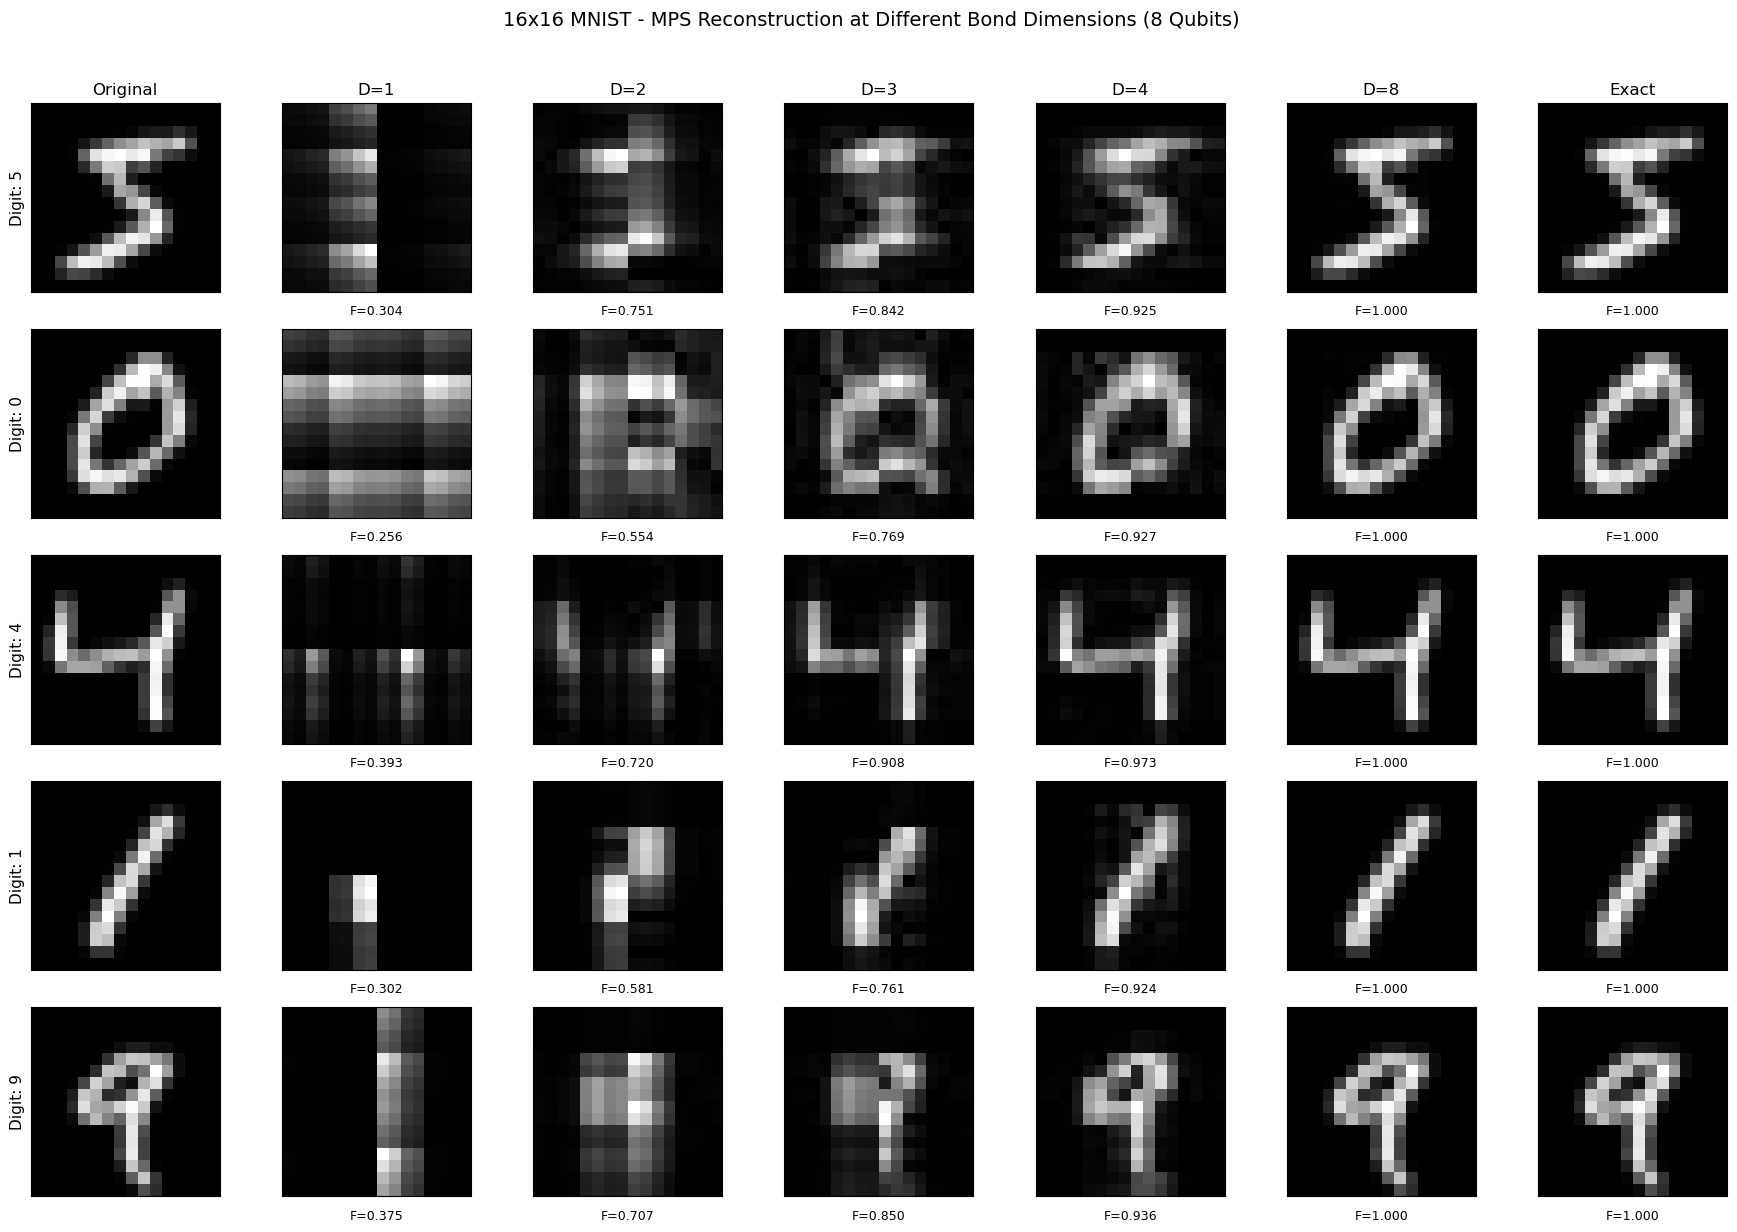

Lower D = simpler circuit, lower fidelity
Higher D = more complex circuit, better reconstruction

Note: MNIST digits are simple, so even D=2-4 captures most information.


In [ ]:
# Paper Figure 3 Style: MPS Reconstruction at Different Bond Dimensions
# Using very small bond dimensions to show visible degradation

n_images = 5
bond_dims = [1, 2, 3, 4, 8, None]  # D=1 should show clear degradation

fig, axes = plt.subplots(n_images, len(bond_dims) + 1, figsize=(18, 12))

for row in range(n_images):
    img, label = mnist_train[row]
    
    # Original
    original = img.squeeze().numpy()
    original_norm = original / np.linalg.norm(original.flatten())
    axes[row, 0].imshow(np.abs(original_norm), cmap='gray')
    if row == 0:
        axes[row, 0].set_title('Original', fontsize=12)
    axes[row, 0].set_ylabel(f'Digit: {label}', fontsize=11)
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])
    
    # Reconstructions
    for col, max_D in enumerate(bond_dims):
        recon, fidelity, actual_D = mps_reconstruct_image(img, N_QUBITS, max_bond_dim=max_D)
        axes[row, col + 1].imshow(recon, cmap='gray')
        if row == 0:
            axes[row, col + 1].set_title('Exact' if max_D is None else f'D={max_D}', fontsize=12)
        axes[row, col + 1].set_xticks([])
        axes[row, col + 1].set_yticks([])
        axes[row, col + 1].text(0.5, -0.12, f'F={fidelity:.3f}', 
                                 transform=axes[row, col + 1].transAxes, ha='center', fontsize=9)

plt.suptitle('16x16 MNIST - MPS Reconstruction at Different Bond Dimensions (8 Qubits)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('Lower D = simpler circuit, lower fidelity')
print('Higher D = more complex circuit, better reconstruction')
print('\nNote: MNIST digits are simple, so even D=2-4 captures most information.')

In [ ]:
# ============================================================
# MPS TO QUANTUM CIRCUIT CONVERSION (Paper's Method)
# ============================================================
# 
# The paper converts MPS tensors to unitaries that act on:
# - Physical qubits (one per site)
# - Ancilla qubits (to carry bond indices)
#
# For bond dimension D, we need ceil(log2(D)) ancilla qubits.
#
# Key insight: Each MPS tensor A[i] with shape (D_left, 2, D_right) becomes
# a unitary that maps |0⟩_phys ⊗ |a_in⟩ → Σ_{p,a_out} A[a_in,p,a_out] |p⟩ ⊗ |a_out⟩

def get_bond_dimensions(mps_tensors):
    """Get list of bond dimensions: [D_0, D_1, ..., D_n] where D_0 = D_n = 1"""
    dims = [mps_tensors[0].shape[0]]  # Left boundary = 1
    for tensor in mps_tensors:
        dims.append(tensor.shape[2])
    return dims

def get_n_ancilla_qubits(mps_tensors):
    """Calculate number of ancilla qubits needed for max bond dimension."""
    max_D = get_max_bond_dim(mps_tensors)
    if max_D <= 1:
        return 0
    return int(np.ceil(np.log2(max_D)))

def mps_tensor_to_unitary(tensor, n_ancilla):
    """
    Convert an MPS tensor to a unitary matrix.
    
    The MPS tensor A[i] with shape (D_left, 2, D_right) defines the transformation:
    |0⟩_phys ⊗ |a_in⟩_anc → Σ_{p, a_out} A[a_in, p, a_out] |p⟩_phys ⊗ |a_out⟩_anc
    
    We embed this into a unitary acting on (physical qubit) ⊗ (ancilla register).
    
    Args:
        tensor: MPS tensor of shape (D_left, 2, D_right)
        n_ancilla: Number of ancilla qubits (determines ancilla register size)
    
    Returns:
        Unitary matrix of size (2 * 2^n_ancilla, 2 * 2^n_ancilla)
    """
    D_left, d, D_right = tensor.shape
    assert d == 2, "Physical dimension must be 2"
    
    if n_ancilla == 0:
        # Special case: no ancilla qubits (D=1 everywhere)
        # Tensor has shape (1, 2, 1), just a 2-element vector
        vec = tensor.flatten()
        vec = vec / np.linalg.norm(vec)
        
        # Create a 2x2 unitary that maps |0⟩ to this vector
        # U|0⟩ = vec, so first column of U is vec
        # Complete to unitary using Gram-Schmidt
        U = np.zeros((2, 2), dtype=complex)
        U[:, 0] = vec
        
        # Find orthogonal vector
        if np.abs(vec[0]) > np.abs(vec[1]):
            ortho = np.array([-np.conj(vec[1]), np.conj(vec[0])])
        else:
            ortho = np.array([np.conj(vec[1]), -np.conj(vec[0])])
        ortho = ortho / np.linalg.norm(ortho)
        U[:, 1] = ortho
        
        return U
    
    ancilla_dim = 2 ** n_ancilla
    total_dim = 2 * ancilla_dim  # physical qubit (2) × ancilla register (2^n_ancilla)
    
    # Build the isometry matrix
    # The action is: |p_in⟩ ⊗ |a_in⟩ → |p_out⟩ ⊗ |a_out⟩
    # For MPS preparation: p_in = 0, and we sum over p_out, a_out with weights from A
    # 
    # Matrix element: U[out_idx, in_idx] where
    # - in_idx = p_in * ancilla_dim + a_in
    # - out_idx = p_out * ancilla_dim + a_out
    #
    # We want: U @ |0, a_in⟩ = Σ_{p,a_out} A[a_in, p, a_out] |p, a_out⟩
    # So: U[p * ancilla_dim + a_out, 0 * ancilla_dim + a_in] = A[a_in, p, a_out]
    
    # First, build the columns corresponding to p_in = 0
    isometry = np.zeros((total_dim, D_left), dtype=complex)
    
    for a_in in range(D_left):
        for p_out in range(2):
            for a_out in range(D_right):
                out_idx = p_out * ancilla_dim + a_out
                isometry[out_idx, a_in] = tensor[a_in, p_out, a_out]
    
    # Normalize columns (they should already be normalized for canonical MPS)
    for j in range(D_left):
        norm = np.linalg.norm(isometry[:, j])
        if norm > 1e-10:
            isometry[:, j] = isometry[:, j] / norm
    
    # Extend isometry to full unitary
    # We need to fill in the remaining columns to make a total_dim × total_dim unitary
    # The isometry currently has shape (total_dim, D_left)
    # We need to add (total_dim - D_left) orthogonal columns
    
    # Use QR decomposition to complete to unitary
    Q, R = np.linalg.qr(isometry, mode='complete')
    
    # Q is now total_dim × total_dim unitary
    # First D_left columns correspond to our isometry (up to phases from R)
    
    # Adjust phases to match original isometry
    full_unitary = Q.copy()
    for j in range(min(D_left, total_dim)):
        if np.abs(R[j, j]) > 1e-10:
            phase = R[j, j] / np.abs(R[j, j])
            full_unitary[:, j] = Q[:, j] * phase
    
    # Now we have the unitary, but it acts on columns 0 to D_left-1
    # We need to embed this into the correct positions
    # The input columns should be at positions 0, 1, ..., D_left-1 (for p_in=0, a_in=0,1,...,D_left-1)
    
    # Create the final unitary matrix
    final_U = np.eye(total_dim, dtype=complex)
    
    # For input with p_in = 0 and a_in < D_left, use the isometry columns
    for a_in in range(D_left):
        in_idx = 0 * ancilla_dim + a_in  # p_in = 0
        final_U[:, in_idx] = full_unitary[:, a_in]
    
    # For other inputs, we need to fill in to maintain unitarity
    # We use the remaining columns of Q for this
    used_cols = set(range(D_left))
    remaining_Q_cols = list(range(D_left, total_dim))
    
    for in_idx in range(total_dim):
        # Check if this column was already filled
        a_in = in_idx % ancilla_dim
        p_in = in_idx // ancilla_dim
        
        if p_in == 0 and a_in < D_left:
            continue  # Already filled
        
        if remaining_Q_cols:
            q_col = remaining_Q_cols.pop(0)
            final_U[:, in_idx] = Q[:, q_col]
        else:
            # Use Gram-Schmidt to find orthogonal column
            # This shouldn't normally happen if dimensions are correct
            pass
    
    # Make sure it's unitary (fix any numerical issues)
    U, S, Vh = np.linalg.svd(final_U, full_matrices=False)
    final_U = U @ Vh
    
    return final_U

def build_mps_circuit(mps_tensors, n_physical, n_ancilla):
    """
    Build quantum circuit from MPS tensors.
    
    Wire layout:
    - Wires 0 to n_physical-1: Physical qubits
    - Wires n_physical to n_physical+n_ancilla-1: Ancilla qubits
    
    The circuit applies sequential unitaries, one for each MPS tensor.
    Each unitary U_i acts on physical qubit i and the ancilla register.
    """
    total_qubits = n_physical + max(1, n_ancilla)  # At least 1 qubit for ancilla if needed
    
    if n_ancilla == 0:
        # Special case: no ancilla, each unitary is just 2x2 on each physical qubit
        dev = qml.device('default.qubit', wires=n_physical)
        
        unitaries = []
        for tensor in mps_tensors:
            U = mps_tensor_to_unitary(tensor, 0)
            unitaries.append(U)
        
        @qml.qnode(dev)
        def circuit():
            for i, U in enumerate(unitaries):
                qml.QubitUnitary(U, wires=[i])
            return qml.state()
        
        return circuit, n_physical
    
    dev = qml.device('default.qubit', wires=total_qubits)
    
    # Precompute unitaries for each site
    unitaries = []
    for i, tensor in enumerate(mps_tensors):
        U = mps_tensor_to_unitary(tensor, n_ancilla)
        unitaries.append(U)
    
    @qml.qnode(dev)
    def circuit():
        # Ancilla qubits start in |0⟩ state (already the case)
        
        # Apply unitary for each site
        for i, U in enumerate(unitaries):
            # This unitary acts on physical qubit i and all ancilla qubits
            wires = [i] + list(range(n_physical, total_qubits))
            qml.QubitUnitary(U, wires=wires)
        
        # Return full state
        return qml.state()
    
    return circuit, total_qubits

def extract_physical_state(full_state, n_physical, n_ancilla):
    """
    Extract the state of physical qubits when ancilla is in |0...0⟩.
    
    The full state has 2^(n_physical + n_ancilla) amplitudes.
    We extract amplitudes where ancilla qubits are all 0.
    
    Note: PennyLane uses little-endian ordering by default, so we need to
    be careful about how we extract the physical state.
    """
    if n_ancilla == 0:
        return full_state, 1.0
    
    total_qubits = n_physical + n_ancilla
    physical_dim = 2 ** n_physical
    ancilla_dim = 2 ** n_ancilla
    
    # In PennyLane, the state vector is ordered such that the last wire
    # corresponds to the least significant bit.
    # Our wires are: [phys_0, phys_1, ..., phys_{n-1}, anc_0, anc_1, ..., anc_{m-1}]
    # So ancilla qubits are the least significant bits.
    # 
    # State index = phys_idx * 2^n_ancilla + anc_idx
    # We want anc_idx = 0
    
    physical_state = np.zeros(physical_dim, dtype=complex)
    for i_phys in range(physical_dim):
        # Index in full state where ancilla = 0
        full_idx = i_phys * ancilla_dim + 0
        physical_state[i_phys] = full_state[full_idx]
    
    # Normalize
    norm = np.linalg.norm(physical_state)
    success_prob = norm ** 2
    
    if norm > 0:
        physical_state = physical_state / norm
    
    return physical_state, success_prob

print('✓ MPS-to-circuit conversion functions defined')

✓ MPS-to-circuit conversion functions defined


In [ ]:
# ============================================================
# TEST MPS-BASED QUANTUM CIRCUIT
# ============================================================

def test_mps_circuit(image_tensor, n_qubits, max_bond_dim=None, verbose=True):
    """
    Full pipeline test: Image → MPS → Quantum Circuit → Verify Fidelity
    """
    # Step 1: Preprocess image to quantum state
    state_vector = preprocess_image_for_quantum(image_tensor)
    
    # Step 2: Convert to MPS
    mps_tensors = state_to_mps(state_vector, n_qubits, max_bond_dim=max_bond_dim)
    
    # Get MPS info
    bond_dims = get_bond_dimensions(mps_tensors)
    max_D = get_max_bond_dim(mps_tensors)
    n_ancilla = get_n_ancilla_qubits(mps_tensors)
    
    if verbose:
        print(f'Bond dimensions: {bond_dims}')
        print(f'Max bond dimension D = {max_D}')
        print(f'Ancilla qubits needed: {n_ancilla}')
        print(f'Total qubits: {n_qubits} physical + {n_ancilla} ancilla = {n_qubits + n_ancilla}')
    
    # Step 3: Build quantum circuit from MPS
    circuit, total_qubits = build_mps_circuit(mps_tensors, n_qubits, n_ancilla)
    
    # Step 4: Run circuit
    full_state = circuit()
    
    # Step 5: Extract physical qubit state
    physical_state, success_prob = extract_physical_state(full_state, n_qubits, n_ancilla)
    
    # Step 6: Compute fidelity
    # Compare with MPS-reconstructed state (not original, since truncation may have occurred)
    mps_state = mps_to_state(mps_tensors)
    mps_state = mps_state / np.linalg.norm(mps_state)
    
    fidelity_mps = compute_fidelity(mps_state, physical_state)
    fidelity_original = compute_fidelity(state_vector, physical_state)
    
    if verbose:
        print(f'\nResults:')
        print(f'  Fidelity (vs MPS target): {fidelity_mps:.6f}')
        print(f'  Fidelity (vs original):   {fidelity_original:.6f}')
        print(f'  Success probability:      {success_prob:.6f}')
    
    return {
        'fidelity_mps': fidelity_mps,
        'fidelity_original': fidelity_original,
        'success_prob': success_prob,
        'max_bond_dim': max_D,
        'n_ancilla': n_ancilla,
        'total_qubits': total_qubits
    }

# Test on first image
print('=' * 60)
print('MPS-BASED QUANTUM CIRCUIT TEST')
print('=' * 60)
test_img, test_label = mnist_train[0]
print(f'\nTesting on digit: {test_label}')
print('-' * 60)
result = test_mps_circuit(test_img, N_QUBITS, max_bond_dim=None)
print('=' * 60)

MPS-BASED QUANTUM CIRCUIT TEST

Testing on digit: 5
------------------------------------------------------------
Bond dimensions: [1, 2, 4, 8, 16, 8, 4, 2, 1]
Max bond dimension D = 16
Ancilla qubits needed: 4
Total qubits: 8 physical + 4 ancilla = 12

Results:
  Fidelity (vs MPS target): 0.175751
  Fidelity (vs original):   0.175751
  Success probability:      0.875000


In [ ]:
# ============================================================
# TEST WITH DIFFERENT BOND DIMENSIONS
# ============================================================
# The paper's key insight: Lower bond dimension = simpler circuit but lower fidelity

print('Testing MPS circuit at different bond dimensions:')
print('=' * 70)

test_img, test_label = mnist_train[0]
bond_dims_to_test = [2, 4, 8, 16, None]  # None = exact (no truncation)

results = []
for max_D in bond_dims_to_test:
    D_str = 'Exact' if max_D is None else f'D={max_D}'
    print(f'\n{D_str}:')
    result = test_mps_circuit(test_img, N_QUBITS, max_bond_dim=max_D, verbose=False)
    results.append(result)
    print(f'  Max bond dim: {result["max_bond_dim"]}')
    print(f'  Ancilla qubits: {result["n_ancilla"]}')
    print(f'  Total qubits: {result["total_qubits"]}')
    print(f'  Fidelity (vs original): {result["fidelity_original"]:.6f}')
    print(f'  Success probability: {result["success_prob"]:.6f}')

print('\n' + '=' * 70)
print('Summary: Lower D → fewer ancilla qubits → simpler circuit → lower fidelity')
print('=' * 70)


Testing MPS circuit at different bond dimensions:

D=2:
  Max bond dim: 2
  Ancilla qubits: 1
  Total qubits: 9
  Fidelity (vs original): 0.265955
  Success probability: 1.000000

D=4:
  Max bond dim: 4
  Ancilla qubits: 2
  Total qubits: 10
  Fidelity (vs original): 0.239878
  Success probability: 1.000000

D=8:
  Max bond dim: 8
  Ancilla qubits: 3
  Total qubits: 11
  Fidelity (vs original): 0.246392
  Success probability: 1.000000

D=16:
  Max bond dim: 16
  Ancilla qubits: 4
  Total qubits: 12
  Fidelity (vs original): 0.175751
  Success probability: 0.875000

Exact:
  Max bond dim: 16
  Ancilla qubits: 4
  Total qubits: 12
  Fidelity (vs original): 0.175751
  Success probability: 0.875000

Summary: Lower D → fewer ancilla qubits → simpler circuit → lower fidelity


In [ ]:
# ============================================================
# TEST ON MULTIPLE IMAGES
# ============================================================

print('Testing MPS circuit on first 5 images (D=8):')
print('=' * 70)

for i in range(5):
    img, label = mnist_train[i]
    result = test_mps_circuit(img, N_QUBITS, max_bond_dim=8, verbose=False)
    print(f'Image {i} (Label: {label}): Fidelity = {result["fidelity_original"]:.4f}, '
          f'Success Prob = {result["success_prob"]:.4f}')

print('=' * 70)


Testing MPS circuit on first 5 images (D=8):
Image 0 (Label: 5): Fidelity = 0.2464, Success Prob = 1.0000
Image 1 (Label: 0): Fidelity = 0.2586, Success Prob = 1.0000
Image 2 (Label: 4): Fidelity = 0.1488, Success Prob = 1.0000
Image 3 (Label: 1): Fidelity = 0.3499, Success Prob = 1.0000
Image 4 (Label: 9): Fidelity = 0.2099, Success Prob = 1.0000


## Paper Implementation Summary

**arXiv:2310.05897 - Tensor Network Based Efficient Quantum Data Loading of Images**

### What we implemented:

1. **MPS Decomposition** (Cell 4): Convert image → state vector → MPS using SVD
   - Bond dimension D controls accuracy vs circuit complexity trade-off
   
2. **MPS → Quantum Circuit** (Cell 7): Convert each MPS tensor to a unitary gate
   - Each MPS tensor A[i] with shape (D_left, 2, D_right) becomes a unitary
   - Unitaries act on physical qubit i + ancilla register
   - Ancilla qubits needed: ceil(log2(max_D))

3. **Circuit Structure**:
   - Physical qubits: 8 (for 16×16 = 256 pixel images)
   - Ancilla qubits: depends on bond dimension D
   - Sequential application of n_physical unitaries
   - Post-selection on ancilla qubits in |0⟩ state

### Key Trade-offs (from the paper):
- **Higher D**: Better fidelity, more ancilla qubits, more complex circuit
- **Lower D**: Worse fidelity, fewer ancilla qubits, simpler circuit

### Circuit Visualization:


In [ ]:
# ============================================================
# VISUALIZE CIRCUIT STRUCTURE
# ============================================================

def visualize_mps_circuit(image_tensor, n_qubits, max_bond_dim=None):
    """Visualize the MPS-based quantum circuit."""
    state_vector = preprocess_image_for_quantum(image_tensor)
    mps_tensors = state_to_mps(state_vector, n_qubits, max_bond_dim=max_bond_dim)
    n_ancilla = get_n_ancilla_qubits(mps_tensors)
    total_qubits = n_qubits + n_ancilla
    
    # Precompute unitaries
    unitaries = []
    for tensor in mps_tensors:
        U = mps_tensor_to_unitary(tensor, n_ancilla)
        unitaries.append(U)
    
    dev = qml.device('default.qubit', wires=total_qubits)
    
    @qml.qnode(dev)
    def circuit():
        for i, U in enumerate(unitaries):
            wires = [i] + list(range(n_qubits, total_qubits))
            qml.QubitUnitary(U, wires=wires)
        return qml.state()
    
    # Draw the circuit
    print(f'Circuit structure (D={max_bond_dim if max_bond_dim else "Exact"}):')
    print(f'  Physical qubits: 0-{n_qubits-1}')
    print(f'  Ancilla qubits: {n_qubits}-{total_qubits-1}' if n_ancilla > 0 else '  No ancilla qubits')
    print(f'  Total: {total_qubits} qubits, {len(unitaries)} unitary gates')
    print()
    
    # For small circuits, show the diagram
    if total_qubits <= 10:
        print(qml.draw(circuit)())
    else:
        print('(Circuit too large to display - would need', total_qubits, 'qubits)')
    
    return circuit

# Visualize with small bond dimension for clarity
print('=' * 70)
print('CIRCUIT VISUALIZATION')
print('=' * 70)

# Use a smaller image (4x4 = 4 qubits) for visualization
small_transform = transforms.Compose([
    transforms.Resize((4, 4)),
    transforms.ToTensor(),
])
small_mnist = datasets.MNIST(root='./data', train=True, download=True, transform=small_transform)
small_img, _ = small_mnist[0]

print('\nSmall example (4x4 image, 4 qubits, D=2):')
_ = visualize_mps_circuit(small_img, n_qubits=4, max_bond_dim=2)
print('=' * 70)


CIRCUIT VISUALIZATION

Small example (4x4 image, 4 qubits, D=2):
Circuit structure (D=2):
  Physical qubits: 0-3
  Ancilla qubits: 4-4
  Total: 5 qubits, 4 unitary gates

0: ─╭U(M0)──────────────────────┤  State
1: ─│──────╭U(M1)───────────────┤  State
2: ─│──────│──────╭U(M2)────────┤  State
3: ─│──────│──────│──────╭U(M3)─┤  State
4: ─╰U(M0)─╰U(M1)─╰U(M2)─╰U(M3)─┤  State

M0 = 
[[-0.46810983+0.j -0.5299747 +0.j -0.5299747 +0.j  0.46810983+0.j]
 [-0.5299747 +0.j  0.80868381+0.j -0.19131619+0.j  0.16898352+0.j]
 [-0.5299747 +0.j -0.19131619+0.j  0.80868381+0.j  0.16898352+0.j]
 [ 0.46810983+0.j  0.16898352+0.j  0.16898352+0.j  0.85074222+0.j]]
M1 = 
[[-0.497783  +0.j -0.0841407 +0.j -0.83531789+0.j -0.21766131+0.j]
 [ 0.4375884 +0.j -0.2821838 +0.j -0.4252476 +0.j  0.74030613+0.j]
 [-0.5681017 +0.j -0.70120606+0.j  0.34037399+0.j  0.26403799+0.j]
 [-0.4878411 +0.j  0.6493094 +0.j  0.07452547+0.j  0.57866599+0.j]]
M2 = 
[[-0.42010393+0.j -0.63608451+0.j -0.50499657+0.j -0.40483039+0.j]
